> 🔎 **원본(HD 1920×1080) 버전** — 입력 `clips_hd`, 결과 `auto_D6_spit_up_hd.csv`. 240p 결과와 검출률 비교가 목적.

# D6_spit_up — 무라벨(라벨링 없이) 획득

힌트의 두 축을 모두 채택하고 오디오 신호를 추가해 3중 결합 의사라벨을 만든다. (1) OWL-ViT 제로샷 오픈보캐뷸러리 검출로 "spit up milk" 등 쿼리를 2배 업스케일 프레임에 적용하고, (2) MediaPipe(BlazeFace) 입 중심 키포인트 기반 입~턱 ROI에서 피부 중앙값 대비 밝은 픽셀 비율이 클립 초반 기준선 대비 급증하는지 측정하며(주간/야간 IR 모두 우유·토사물이 밝은 얼룩으로 나타나 조명 불변), (3) AudioSet 사전학습 AST로 기침/트림/구역질 계열 소리를 점수화한다. 세 점수를 가중 결합한 spit_score와 이진 pseudo_label을 BASE/auto_D6_spit_up.csv에 증분 저장하고, 분포 히스토그램과 상위 사례 시각화로 임계값을 조정한다.

In [1]:
# 설치 셀 — 처음 실행 후 protobuf/numpy 경고가 나오면: 런타임 → 세션 다시 시작 → 이어서 실행
!pip install -q mediapipe==0.10.14 transformers torchaudio av decord
!pip -q uninstall -y tensorflow  # mediapipe 0.10.14(protobuf4)와 TF(protobuf5) 충돌 방지 — 이 노트북은 TF 미사용

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [2]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

# ── HD(원본) 모드: clips_hd 를 우선 사용 ─────────────────────────
_hd = BASE/'clips_hd'
if _hd.is_dir() and next(_hd.glob('*.mp4'), None):
    CLIPS = _hd
    print('HD 모드: ', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 (1920x1080)')
else:
    raise SystemExit('clips_hd 없음 — D:\\carved\\dataset\\clips_hd 를 Drive 의 dataset/clips_hd 로 업로드하세요')

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080
HD 모드:  /content/drive/MyDrive/BabyMon/dataset/clips_hd 5395 개 (1920x1080)


## D6_spit_up — 토 징조/토함 자동 의사라벨 (수동 라벨링 없음)

**세 가지 독립 신호를 결합**해 클립별 `spit_score` 와 이진 `pseudo_label` 을 만든다.

1. **오픈보캐뷸러리 제로샷 검출 (OWL-ViT)** — "spit up milk", "white vomit stain" 등 텍스트 쿼리로 토사물/우유 얼룩을 직접 검출. 240x136 저해상도이므로 2배 업스케일 후 추론.
   출처: [Simple Open-Vocabulary Object Detection with Vision Transformers (ECCV 2022)](https://arxiv.org/abs/2205.06230)
2. **입 주변 ROI 밝은 픽셀 급증 휴리스틱** — MediaPipe(BlazeFace) 얼굴 검출의 입 중심 키포인트로 입~턱 ROI 를 정의하고, 얼굴 피부 중앙값 대비 밝은 픽셀 비율이 클립 초반(기준선) 대비 급증하는지 측정. 주간 컬러/야간 IR 흑백 모두에서 우유·토사물은 '밝은 얼룩'으로 나타나 조명 조건에 거의 불변.
   출처: [BlazeFace (arXiv 2019)](https://arxiv.org/abs/1907.05047)
3. **오디오 이벤트 (AST, AudioSet 527클래스)** — 토하기 전후에 흔한 기침/트림/구역질/딸꾹질 소리를 AudioSet 사전학습 분류기로 점수화 (cough/burp/gag/vomit/hiccup/choke 계열 클래스의 max 확률).
   출처: [AST: Audio Spectrogram Transformer (Interspeech 2021)](https://www.isca-archive.org/interspeech_2021/gong21b_interspeech.html)

결합: `spit_score = 0.5·min(4·owl, 1) + 0.3·min(4·surge, 1) + 0.2·audio` — 계수/임계값은 휴리스틱이며 검증 셀의 분포를 보고 조정한다. 결과는 `BASE/auto_D6_spit_up.csv` 에 증분 저장.

In [3]:
# 모델 초기화 (T4 1개로 충분: OWL-ViT base ~600MB + AST ~350MB)
import torch, cv2, av, json, numpy as np
import mediapipe as mp
import torchaudio
from decord import VideoReader, cpu
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from transformers import ASTFeatureExtractor, ASTForAudioClassification

DEV = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1) 오픈보캐뷸러리 제로샷 검출: OWL-ViT
owl_proc = OwlViTProcessor.from_pretrained('google/owlvit-base-patch32')
owl = OwlViTForObjectDetection.from_pretrained('google/owlvit-base-patch32').to(DEV).eval()
OWL_QUERIES = ['spit up milk', 'white vomit stain', 'milk on baby face',
               'wet white patch on chin']

# 2) 오디오 이벤트: AST (AudioSet 527클래스) -> 구토 관련 클래스만 사용
AST_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'
ast_fe = ASTFeatureExtractor.from_pretrained(AST_ID)
ast_model = ASTForAudioClassification.from_pretrained(AST_ID).to(DEV).eval()
KEYS = ['cough', 'burp', 'gag', 'vomit', 'hiccup', 'choke', 'throat clear']
AUDIO_IDX = [i for i, l in ast_model.config.id2label.items()
             if any(k in l.lower() for k in KEYS)]
print('AudioSet 관련 클래스:', [ast_model.config.id2label[i] for i in AUDIO_IDX])

# 3) 얼굴 검출: MediaPipe(BlazeFace) -> 입 중심 키포인트로 ROI 정의
mp_face = mp.solutions.face_detection.FaceDetection(
    model_selection=1, min_detection_confidence=0.3)  # 1 = full-range (홈캠 거리)

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AudioSet 관련 클래스: ['Cough', 'Throat clearing', 'Burping, eructation', 'Hiccup']


In [4]:
def sample_frames(path, k=6):
    """클립에서 k개 프레임 균등 샘플 (RGB uint8)."""
    vr = VideoReader(str(path), ctx=cpu(0))
    idx = np.linspace(0, len(vr) - 1, k).astype(int)
    return list(vr.get_batch(idx).asnumpy())

def load_audio_16k(path):
    """AAC 8kHz mono -> 16kHz float32. 오디오 없거나 실패 시 None."""
    try:  # 오디오 스트림이 없으면 IndexError -> None
        c = av.open(str(path))
        s = c.streams.audio[0]
        wav = np.concatenate([fr.to_ndarray().reshape(-1) for fr in c.decode(s)])
        sr = s.rate or 8000
        c.close()
        return torchaudio.functional.resample(
            torch.from_numpy(wav.astype(np.float32)), sr, 16000).numpy()
    except Exception:
        return None

def mouth_bright_frac(rgb):
    """입~턱 ROI에서 피부 대비 '흰/밝은' 픽셀 비율. 얼굴 미검출 시 None."""
    try:  # mediapipe legacy solution API — 실패 가능성 있어 전체를 감쌈
        res = mp_face.process(rgb)
        if not res.detections:
            return None
        d = res.detections[0]
        h, w = rgb.shape[:2]
        bb = d.location_data.relative_bounding_box
        kp = d.location_data.relative_keypoints[3]  # 3 = 입 중심 키포인트
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        fx, fy = max(int(bb.xmin * w), 0), max(int(bb.ymin * h), 0)
        fw, fh = max(int(bb.width * w), 1), max(int(bb.height * h), 1)
        face = gray[fy:fy + fh, fx:fx + fw]
        if face.size == 0:
            return None
        thr = float(np.clip(np.median(face) * 1.35, 90, 250))  # 휴리스틱 임계
        cx, cy = int(kp.x * w), int(kp.y * h)
        rx, ry = max(int(fw * 0.30), 3), max(int(fh * 0.35), 3)  # 입에서 턱 아래로 확장
        roi = gray[max(cy - ry // 3, 0):min(cy + ry, h), max(cx - rx, 0):min(cx + rx, w)]
        return float((roi > thr).mean()) if roi.size else None
    except Exception:
        return None

@torch.no_grad()
def owl_score(frames):
    """OWL-ViT 제로샷: 2배 업스케일 프레임들에서 최대 점수 + 해당 쿼리."""
    imgs = [cv2.resize(f, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC) for f in frames]
    inputs = owl_proc(text=[OWL_QUERIES] * len(imgs), images=imgs,
                      return_tensors='pt').to(DEV)
    logits = owl(**inputs).logits             # (B, num_patches, num_queries)
    best = torch.sigmoid(logits).amax(dim=1)  # (B, num_queries)
    v, q = best.max(dim=1)
    b = int(v.argmax())
    return float(v[b]), OWL_QUERIES[int(q[b])]

In [5]:
@torch.no_grad()
def process_clip(fname):
    """클립 1개 -> 신호별 점수 dict. 실패해도 dict는 반환."""
    out = {'file': fname, 'owl_max': 0.0, 'owl_query': '', 'mouth_surge': 0.0,
           'face_frac': 0.0, 'audio_gag': 0.0, 'spit_score': 0.0,
           'pseudo_label': 0, 'error': ''}
    p = CLIPS / fname
    try:
        frames = sample_frames(p, 6)
    except Exception as e:
        out['error'] = f'video:{e}'
        return out
    try:  # (1) 오픈보캐뷸러리 검출 — 처음/중간/끝 3프레임만 (속도)
        out['owl_max'], out['owl_query'] = owl_score(
            [frames[0], frames[len(frames) // 2], frames[-1]])
    except Exception as e:
        out['error'] += f'owl:{e};'
    # (2) 입 주변 밝은 픽셀 비율의 급증 (클립 초반 기준선 대비)
    fr = [mouth_bright_frac(f) for f in frames]
    valid = [x for x in fr if x is not None]
    out['face_frac'] = round(len(valid) / len(fr), 3)
    if len(valid) >= 3:
        base = float(np.median(valid[:2]))
        out['mouth_surge'] = round(max(0.0, max(valid[2:]) - base), 4)
    # (3) 오디오: 기침/트림/구역질 계열 AudioSet 확률
    wav = load_audio_16k(p)
    if wav is not None and len(wav) > 1600:
        try:
            feat = ast_fe(wav, sampling_rate=16000, return_tensors='pt').to(DEV)
            probs = torch.sigmoid(ast_model(**feat).logits)[0]
            out['audio_gag'] = round(float(probs[AUDIO_IDX].max()), 4)
        except Exception as e:
            out['error'] += f'audio:{e};'
    # 결합 점수 — 스케일 계수는 휴리스틱, 검증 셀 분포 보고 조정
    out['spit_score'] = round(0.5 * min(out['owl_max'] * 4, 1.0)
                              + 0.3 * min(out['mouth_surge'] * 4, 1.0)
                              + 0.2 * out['audio_gag'], 4)
    out['pseudo_label'] = int(out['spit_score'] >= 0.5)
    return out

print(process_clip(man.iloc[0]['file']))  # 스모크 테스트

{'file': '2026-06-30_07-55-21.mp4', 'owl_max': 0.03660203143954277, 'owl_query': 'milk on baby face', 'mouth_surge': 0.0, 'face_frac': 0.0, 'audio_gag': 0.0004, 'spit_score': 0.0733, 'pseudo_label': 0, 'error': ''}


In [6]:
import pandas as pd, time

N_CLIPS = 1000
OUT = BASE / 'auto_D6_spit_up_hd.csv'

done = set()
if OUT.exists():
    done = set(pd.read_csv(OUT)['file'])
    print(f'기존 처리 {len(done)}개 건너뜀')

cand = man.sample(n=min(N_CLIPS, len(man)), random_state=42)['file'].tolist()
todo = [f for f in cand if f not in done]
print(f'처리 대상 {len(todo)}개')

buf, t0 = [], time.time()
for i, f in enumerate(todo, 1):
    buf.append(process_clip(f))
    if i % 50 == 0 or i == len(todo):
        pd.DataFrame(buf).to_csv(OUT, mode='a', header=not OUT.exists(), index=False)
        buf = []
        print(f'{i}/{len(todo)} 완료 — 경과 {time.time() - t0:.0f}s')

처리 대상 1000개


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


50/1000 완료 — 경과 91s
100/1000 완료 — 경과 296s
150/1000 완료 — 경과 349s
200/1000 완료 — 경과 405s
250/1000 완료 — 경과 461s
300/1000 완료 — 경과 517s
350/1000 완료 — 경과 571s
400/1000 완료 — 경과 626s
450/1000 완료 — 경과 682s
500/1000 완료 — 경과 737s
550/1000 완료 — 경과 792s
600/1000 완료 — 경과 847s
650/1000 완료 — 경과 903s
700/1000 완료 — 경과 958s
750/1000 완료 — 경과 1014s
800/1000 완료 — 경과 1068s
850/1000 완료 — 경과 1123s
900/1000 완료 — 경과 1178s
950/1000 완료 — 경과 1233s
1000/1000 완료 — 경과 1287s


        owl_max  mouth_surge  audio_gag  spit_score
count  1000.000     1000.000   1000.000    1000.000
mean      0.035        0.000      0.010       0.072
std       0.020        0.003      0.051       0.043
min       0.007        0.000      0.000       0.014
25%       0.025        0.000      0.000       0.051
50%       0.031        0.000      0.001       0.063
75%       0.039        0.000      0.002       0.079
max       0.213        0.064      0.779       0.522
의사라벨 양성: 1 / 1000 | 얼굴 검출률 평균: 0.142


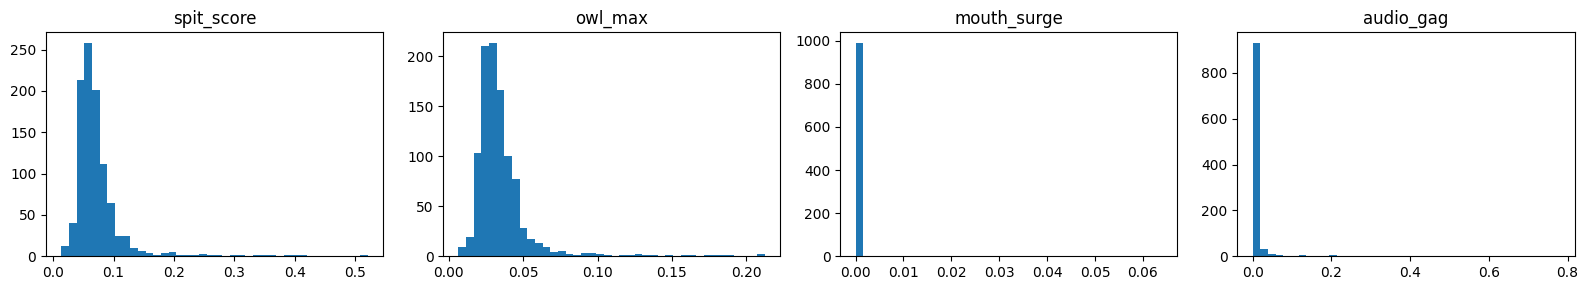

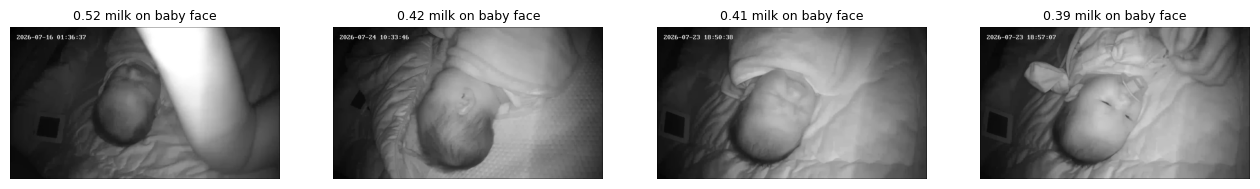

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

res = pd.read_csv(OUT).drop_duplicates('file')
print(res[['owl_max', 'mouth_surge', 'audio_gag', 'spit_score']].describe().round(3))
print('의사라벨 양성:', int(res['pseudo_label'].sum()), '/', len(res),
      '| 얼굴 검출률 평균:', round(res['face_frac'].mean(), 3))

cols = ['spit_score', 'owl_max', 'mouth_surge', 'audio_gag']
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, c in zip(axes, cols):
    ax.hist(res[c].dropna(), bins=40)
    ax.set_title(c)
plt.tight_layout(); plt.show()

# 극단 사례: spit_score 상위 4개 클립의 중간 프레임 눈으로 확인
top = res.nlargest(4, 'spit_score')
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, r) in zip(axes, top.iterrows()):
    try:
        mid = sample_frames(CLIPS / r['file'], 3)[1]
        ax.imshow(mid)
        ax.set_title(f"{r['spit_score']:.2f} {str(r['owl_query'])[:18]}", fontsize=9)
    except Exception as e:
        ax.set_title(f'로드 실패: {e}', fontsize=8)
    ax.axis('off')
plt.show()